# Council Mode — Exploratory Data Analysis

This notebook explores all five benchmark datasets used to evaluate Council Mode's hallucination-reduction capabilities:

| Dataset | Purpose | Size |
|---|---|---|
| **HaluEval QA** | Paired correct/hallucinated answers for hallucination detection | 10,000 |
| **HotpotQA** | Multi-hop reasoning over Wikipedia | 7,405 |
| **MultiHopRAG** | Multi-source retrieval-augmented QA over news | 2,556 |
| **TruthfulQA** | Adversarial questions targeting common misconceptions | 790 |
| **SQuAD v2** | Reading comprehension with unanswerable questions | 500 |

**Key metrics tracked:** question length, answer length, difficulty distribution, category breakdown, word-cloud patterns, cross-dataset comparison.

In [1]:
import os, sys, json, csv, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

# Root path
ROOT = Path("../")
DATA = ROOT / "data" / "documents"

# Consistent style
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.facecolor"] = "#0e1117"
plt.rcParams["axes.facecolor"] = "#1a1a2e"
plt.rcParams["axes.labelcolor"] = "#e0e0e0"
plt.rcParams["xtick.color"] = "#bbbbbb"
plt.rcParams["ytick.color"] = "#bbbbbb"
plt.rcParams["text.color"] = "#e0e0e0"
plt.rcParams["grid.color"] = "#2a2a3e"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = ["#00d2ff", "#ff6b6b", "#feca57", "#2ed573", "#a29bfe", "#fd79a8"]
print("Libraries loaded OK")

Libraries loaded OK


## 1  Load All Datasets

In [ ]:
# HaluEval 
halu_records = []
with open(DATA / "HaluEval_QA.json") as f:
    for line in f:
        line = line.strip()
        if line:
            halu_records.append(json.loads(line))
df_halu = pd.DataFrame(halu_records)

# HotpotQA 
with open(DATA / "HotpotQA_Dev.json") as f:
    df_hotpot = pd.DataFrame(json.load(f))

# MultiHopRAG 
with open(DATA / "MultiHopRAG.json") as f:
    df_mhrag = pd.DataFrame(json.load(f))

df_truth = pd.read_csv(DATA / "TruthfulQA.csv")

#  SQuAD v2 
with open(DATA / "SQuAD_v2_processed.json") as f:
    df_squad = pd.DataFrame(json.load(f))

# Summary
datasets = {
    "HaluEval": df_halu,
    "HotpotQA": df_hotpot,
    "MultiHopRAG": df_mhrag,
    "TruthfulQA": df_truth,
    "SQuAD v2": df_squad,
}
for name, df in datasets.items():
    print(f"{name:>12}  {len(df):>6} rows  |  columns: {list(df.columns)}")

    HaluEval   10000 rows  |  columns: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']
    HotpotQA    7405 rows  |  columns: ['_id', 'answer', 'question', 'supporting_facts', 'context', 'type', 'level']
 MultiHopRAG    2556 rows  |  columns: ['query', 'answer', 'question_type', 'evidence_list']
  TruthfulQA     790 rows  |  columns: ['Type', 'Category', 'Question', 'Best Answer', 'Best Incorrect Answer', 'Correct Answers', 'Incorrect Answers', 'Source']
    SQuAD v2     500 rows  |  columns: ['id', 'question', 'context', 'answer', 'metadata']


## 2  Dataset Size Overview

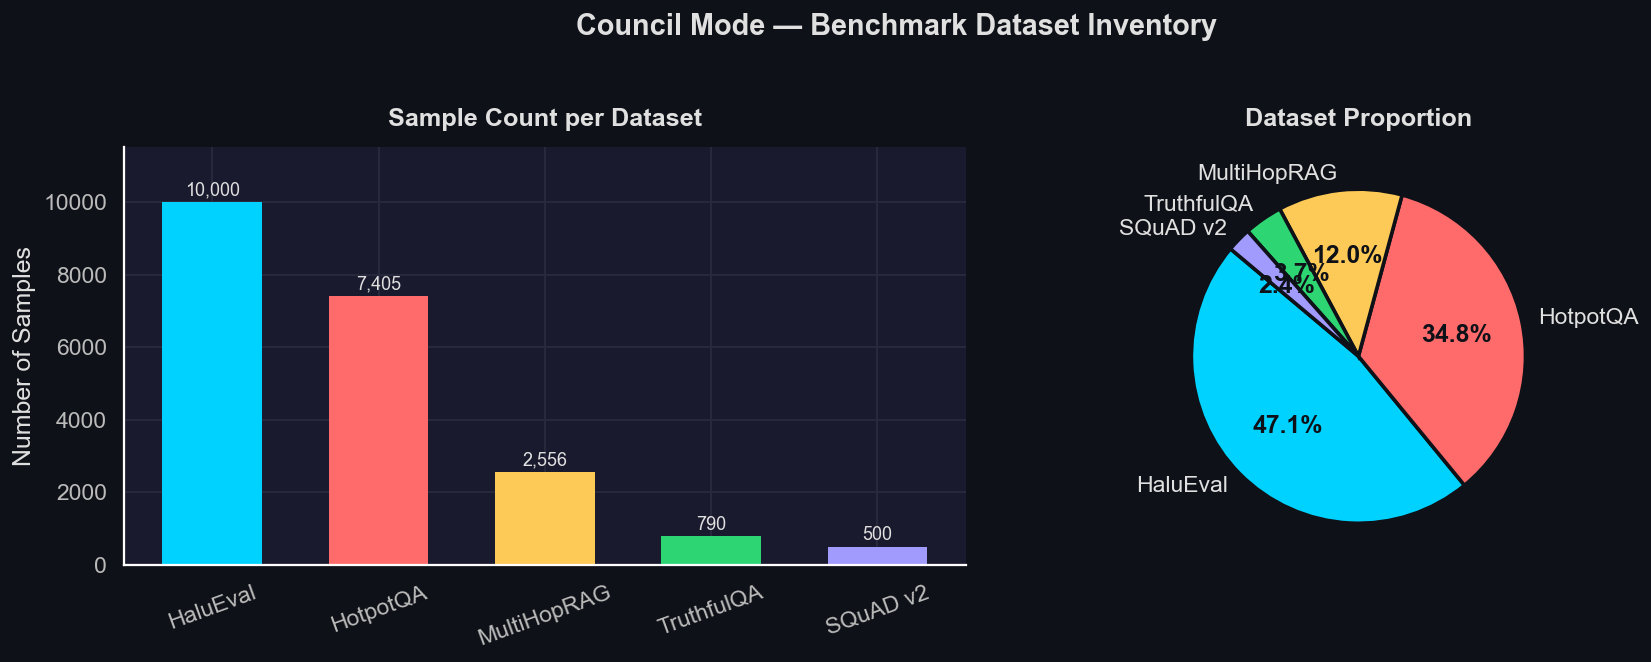

Total samples across all datasets: 21,251


In [3]:
names = list(datasets.keys())
sizes = [len(df) for df in datasets.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0e1117")

# Bar chart
bars = axes[0].bar(names, sizes, color=PALETTE[:5], edgecolor="none", width=0.6)
axes[0].set_title("Sample Count per Dataset", fontsize=14, fontweight="bold", pad=12)
axes[0].set_ylabel("Number of Samples")
for bar, size in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f"{size:,}", ha="center", va="bottom", fontsize=10, color="#e0e0e0")
axes[0].set_ylim(0, max(sizes) * 1.15)
axes[0].tick_params(axis="x", rotation=20)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=names, colors=PALETTE[:5],
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor="#0e1117", linewidth=2),
    textprops=dict(color="#e0e0e0"),
)
for at in autotexts:
    at.set_color("#0e1117")
    at.set_fontweight("bold")
axes[1].set_title("Dataset Proportion", fontsize=14, fontweight="bold", pad=12)
axes[1].set_facecolor("#0e1117")

plt.suptitle("Council Mode — Benchmark Dataset Inventory",
             fontsize=16, fontweight="bold", y=1.02, color="#e0e0e0")
plt.tight_layout()
plt.show()
print(f"Total samples across all datasets: {sum(sizes):,}")

## 3  HaluEval — Hallucination Detection Corpus

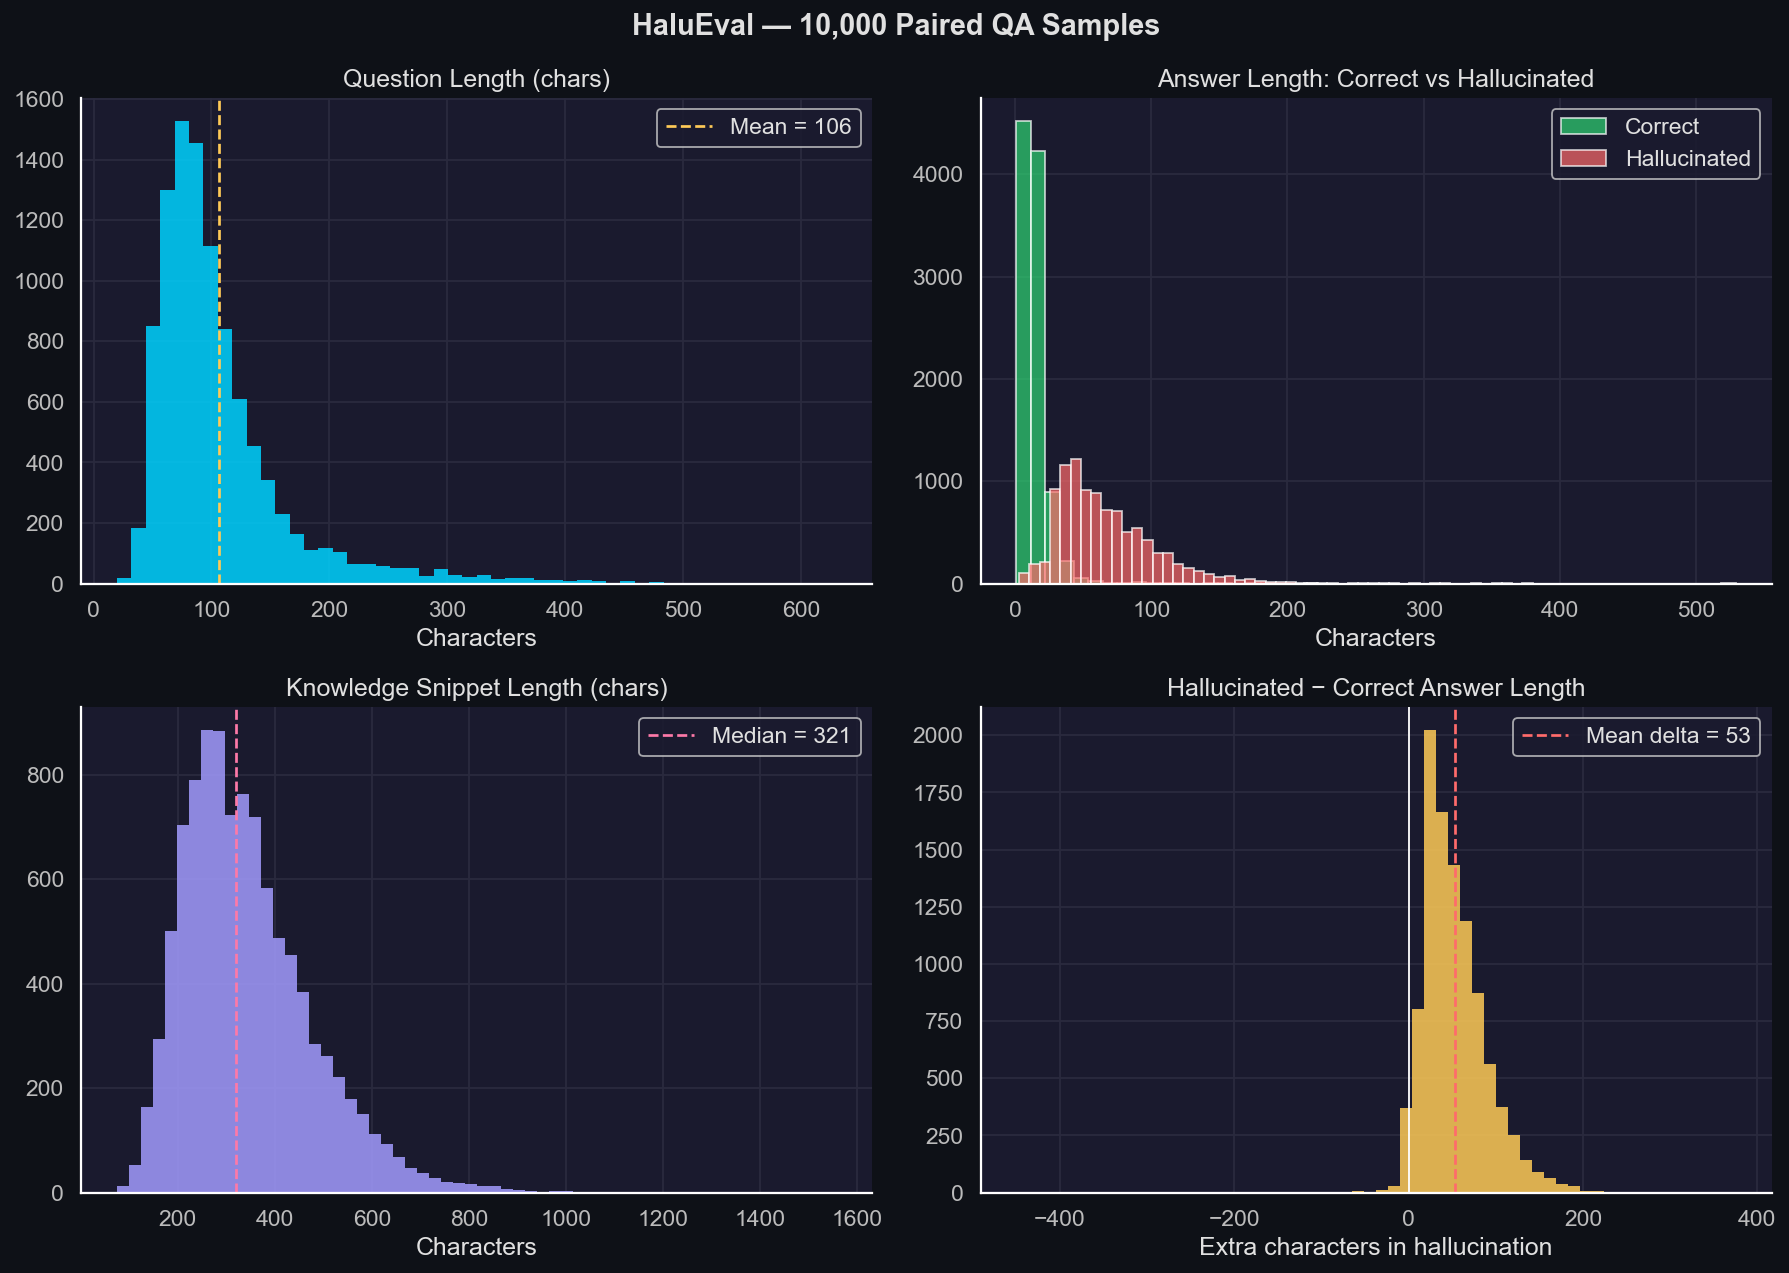

HaluEval stats:
         q_len  right_len  hall_len  know_len
count  10000.0    10000.0   10000.0   10000.0
mean     106.4       13.7      66.2     344.3
std       60.5       12.0      36.3     134.7
min       20.0        1.0       3.0      75.0
25%       70.0        7.0      40.0     247.0
50%       90.0       12.0      58.0     321.0
75%      121.0       17.0      85.0     417.0
max      630.0      529.0     380.0    1557.0


In [4]:
# Compute text lengths
df_halu["q_len"]     = df_halu["question"].str.len()
df_halu["right_len"] = df_halu["right_answer"].str.len()
df_halu["hall_len"]  = df_halu["hallucinated_answer"].str.len()
df_halu["know_len"]  = df_halu["knowledge"].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("HaluEval — 10,000 Paired QA Samples",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# Q length
axes[0,0].hist(df_halu["q_len"], bins=50, color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[0,0].axvline(df_halu["q_len"].mean(), color="#feca57", linestyle="--", lw=1.5,
                   label=f"Mean = {df_halu['q_len'].mean():.0f}")
axes[0,0].set_title("Question Length (chars)")
axes[0,0].set_xlabel("Characters")
axes[0,0].legend()

# Correct vs hallucinated answer lengths
axes[0,1].hist(df_halu["right_len"], bins=50, color=PALETTE[3], alpha=0.7, label="Correct")
axes[0,1].hist(df_halu["hall_len"],  bins=50, color=PALETTE[1], alpha=0.7, label="Hallucinated")
axes[0,1].set_title("Answer Length: Correct vs Hallucinated")
axes[0,1].set_xlabel("Characters")
axes[0,1].legend()

# Knowledge snippet length
axes[1,0].hist(df_halu["know_len"], bins=60, color=PALETTE[4], edgecolor="none", alpha=0.85)
axes[1,0].axvline(df_halu["know_len"].median(), color="#fd79a8", linestyle="--", lw=1.5,
                   label=f"Median = {df_halu['know_len'].median():.0f}")
axes[1,0].set_title("Knowledge Snippet Length (chars)")
axes[1,0].set_xlabel("Characters")
axes[1,0].legend()

# Hallucinated - Correct length delta
df_halu["hall_extra"] = df_halu["hall_len"] - df_halu["right_len"]
axes[1,1].hist(df_halu["hall_extra"], bins=60, color=PALETTE[2], edgecolor="none", alpha=0.85)
axes[1,1].axvline(0, color="white", linestyle="-", lw=1)
axes[1,1].axvline(df_halu["hall_extra"].mean(), color="#ff6b6b", linestyle="--", lw=1.5,
                   label=f"Mean delta = {df_halu['hall_extra'].mean():.0f}")
axes[1,1].set_title("Hallucinated − Correct Answer Length")
axes[1,1].set_xlabel("Extra characters in hallucination")
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("HaluEval stats:")
print(df_halu[["q_len", "right_len", "hall_len", "know_len"]].describe().round(1).to_string())

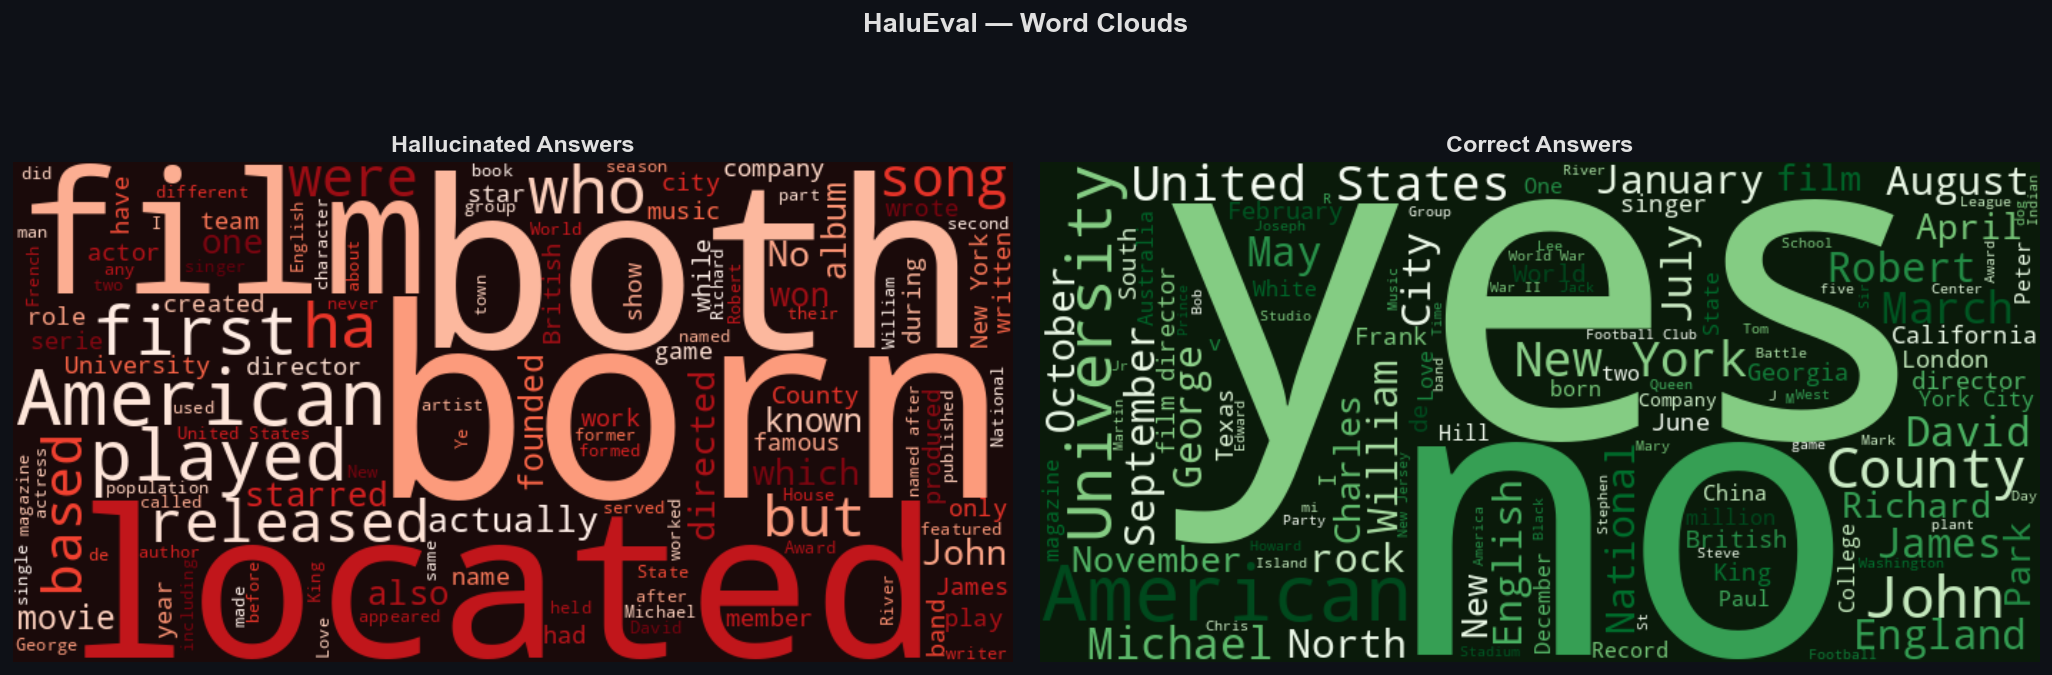

In [5]:
# Word cloud — hallucinated answers (what do hallucinations look like?)
hall_text = " ".join(df_halu["hallucinated_answer"].tolist())
right_text = " ".join(df_halu["right_answer"].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("HaluEval — Word Clouds", fontsize=15, fontweight="bold", color="#e0e0e0")

for ax, text, title, bg, cmap in [
    (axes[0], hall_text, "Hallucinated Answers", "#1a0a0a", "Reds"),
    (axes[1], right_text, "Correct Answers",     "#0a1a0a", "Greens"),
]:
    wc = WordCloud(
        width=700, height=350, background_color=bg,
        colormap=cmap, max_words=120,
        stopwords={"the","a","an","is","was","in","of","and","to","it","that",
                   "for","on","are","at","be","this","with","his","her","not",
                   "as","by","from","or","its","he","she","they"},
        prefer_horizontal=0.7,
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 4  HotpotQA — Multi-Hop Reasoning

/var/folders/92/7fcb7w911b3g8vck3tlsrx1m0000gn/T/ipykernel_12953/649540916.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,2].boxplot(level_data, labels=level_order, patch_artist=True,


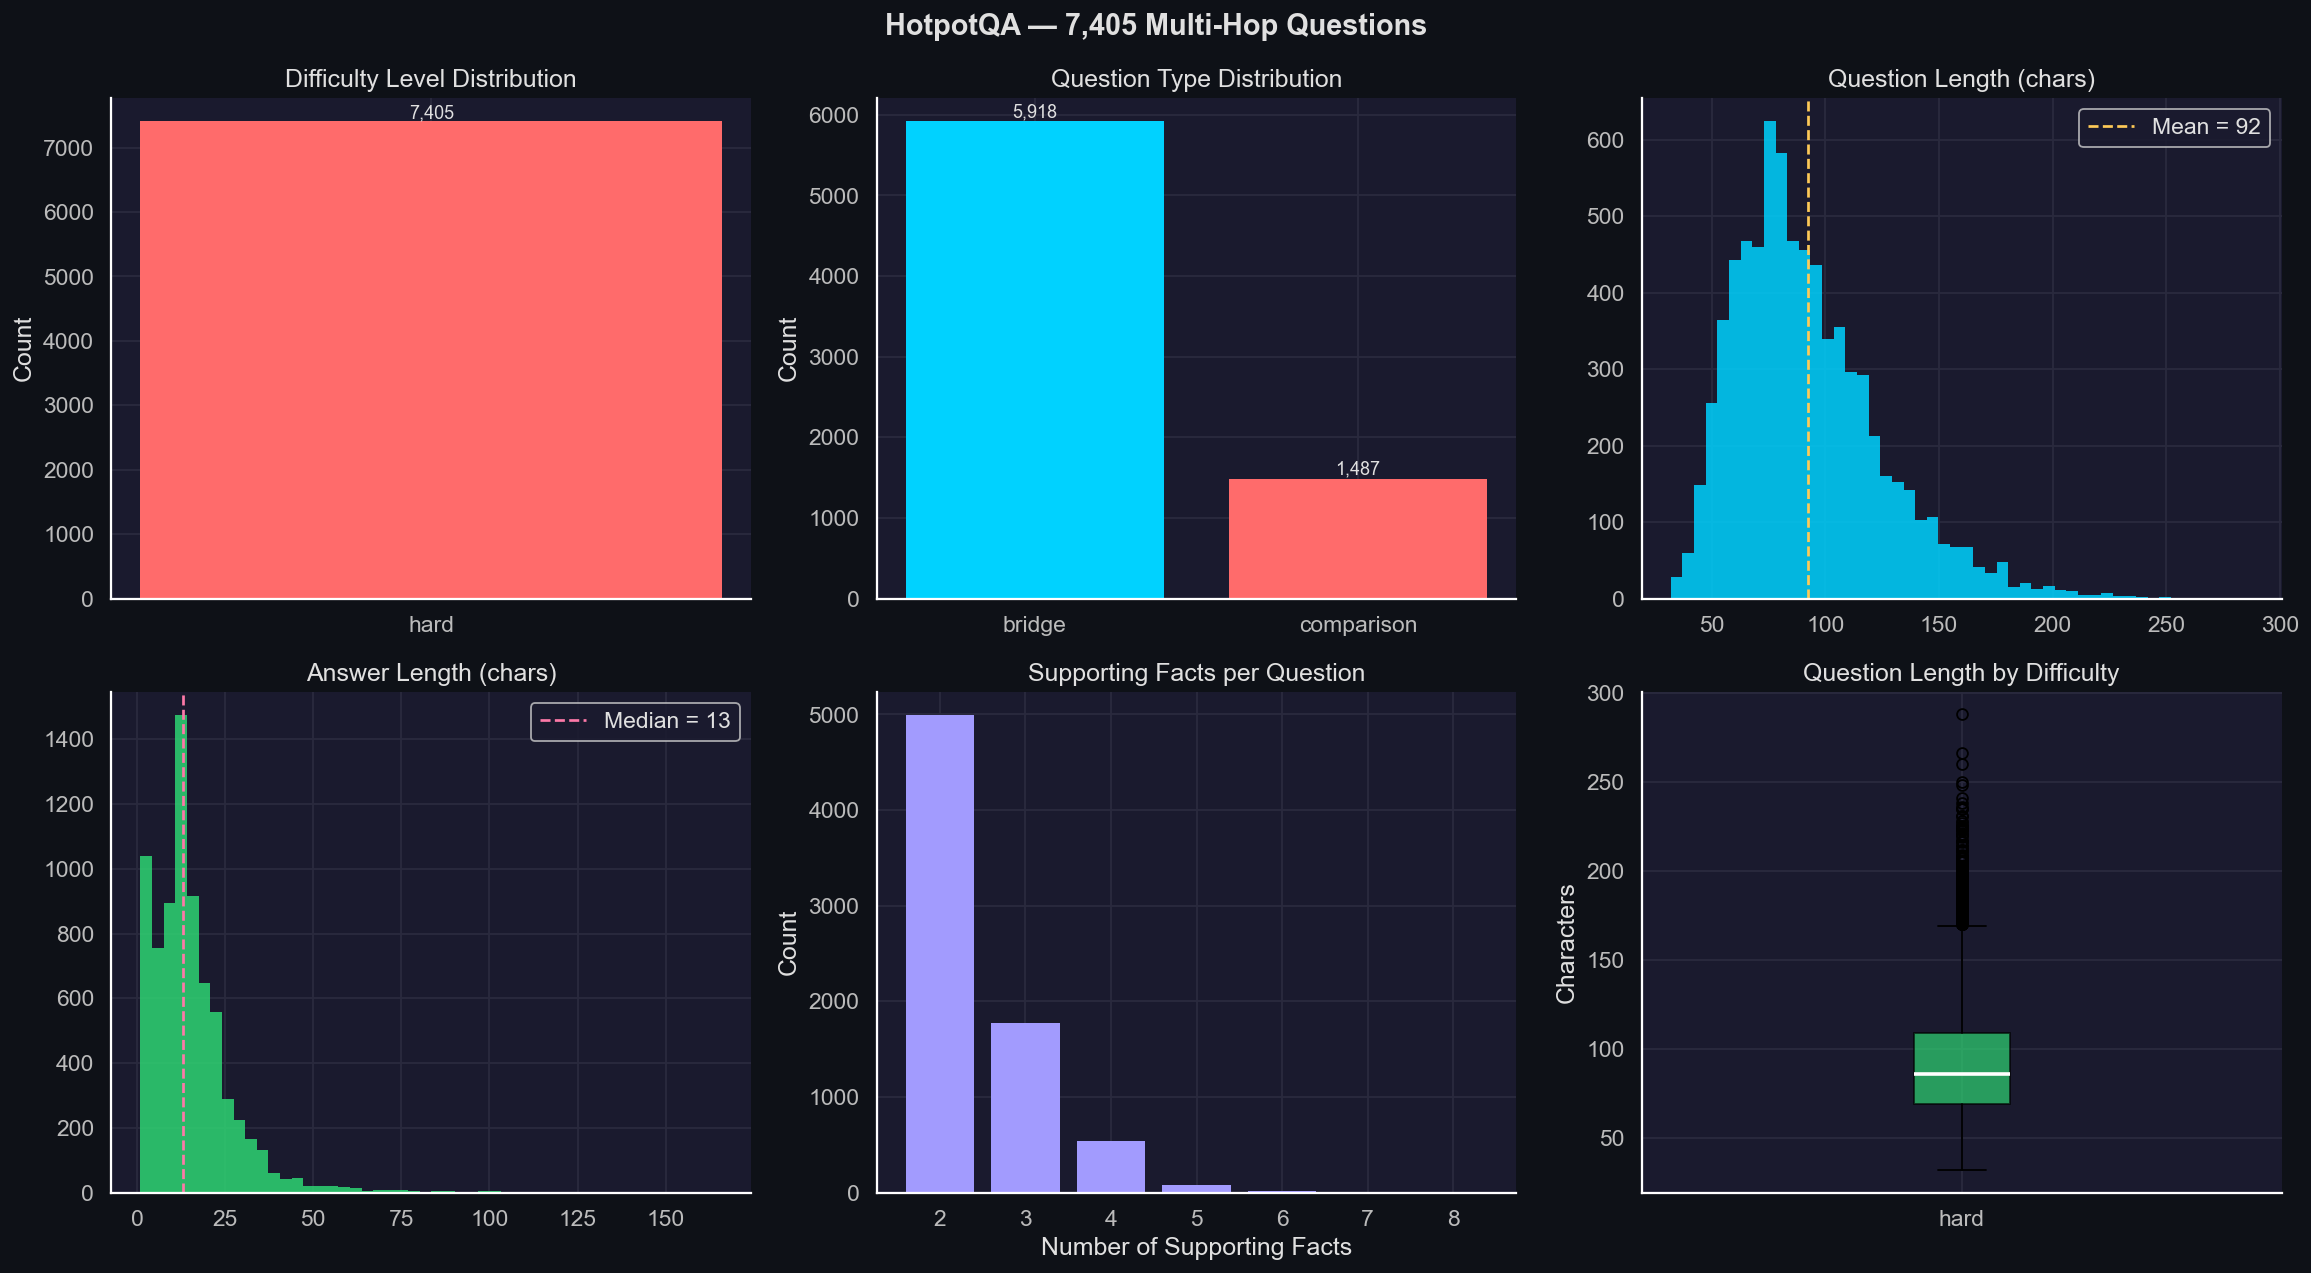

In [6]:
df_hotpot["q_len"]   = df_hotpot["question"].str.len()
df_hotpot["ans_len"] = df_hotpot["answer"].str.len()
df_hotpot["n_supporting"] = df_hotpot["supporting_facts"].apply(len)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("HotpotQA — 7,405 Multi-Hop Questions",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# Difficulty level
level_counts = df_hotpot["level"].value_counts()
axes[0,0].bar(level_counts.index, level_counts.values,
              color=["#ff6b6b", "#feca57", "#2ed573"], edgecolor="none")
axes[0,0].set_title("Difficulty Level Distribution")
axes[0,0].set_ylabel("Count")
for i, (idx, val) in enumerate(level_counts.items()):
    axes[0,0].text(i, val + 50, f"{val:,}", ha="center", fontsize=10, color="#e0e0e0")

# Question type
type_counts = df_hotpot["type"].value_counts()
axes[0,1].bar(type_counts.index, type_counts.values,
              color=PALETTE[:len(type_counts)], edgecolor="none")
axes[0,1].set_title("Question Type Distribution")
axes[0,1].set_ylabel("Count")
for i, (idx, val) in enumerate(type_counts.items()):
    axes[0,1].text(i, val + 50, f"{val:,}", ha="center", fontsize=10, color="#e0e0e0")

# Question length
axes[0,2].hist(df_hotpot["q_len"], bins=50, color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[0,2].axvline(df_hotpot["q_len"].mean(), color="#feca57", linestyle="--", lw=1.5,
                   label=f"Mean = {df_hotpot['q_len'].mean():.0f}")
axes[0,2].set_title("Question Length (chars)")
axes[0,2].legend()

# Answer length
axes[1,0].hist(df_hotpot["ans_len"], bins=50, color=PALETTE[3], edgecolor="none", alpha=0.85)
axes[1,0].axvline(df_hotpot["ans_len"].median(), color="#fd79a8", linestyle="--", lw=1.5,
                   label=f"Median = {df_hotpot['ans_len'].median():.0f}")
axes[1,0].set_title("Answer Length (chars)")
axes[1,0].legend()

# Supporting facts count
sf_counts = df_hotpot["n_supporting"].value_counts().sort_index()
axes[1,1].bar(sf_counts.index.astype(str), sf_counts.values,
              color=PALETTE[4], edgecolor="none")
axes[1,1].set_title("Supporting Facts per Question")
axes[1,1].set_xlabel("Number of Supporting Facts")
axes[1,1].set_ylabel("Count")

# Q length by level (box plot)
level_order = ["easy", "medium", "hard"] if "easy" in df_hotpot["level"].values else df_hotpot["level"].unique()
level_data = [df_hotpot[df_hotpot["level"] == lvl]["q_len"].values for lvl in level_order]
bp = axes[1,2].boxplot(level_data, labels=level_order, patch_artist=True,
                        medianprops=dict(color="white", lw=2))
for patch, color in zip(bp["boxes"], ["#2ed573", "#feca57", "#ff6b6b"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,2].set_title("Question Length by Difficulty")
axes[1,2].set_ylabel("Characters")

plt.tight_layout()
plt.show()

## 5  MultiHopRAG — News-Grounded Retrieval QA

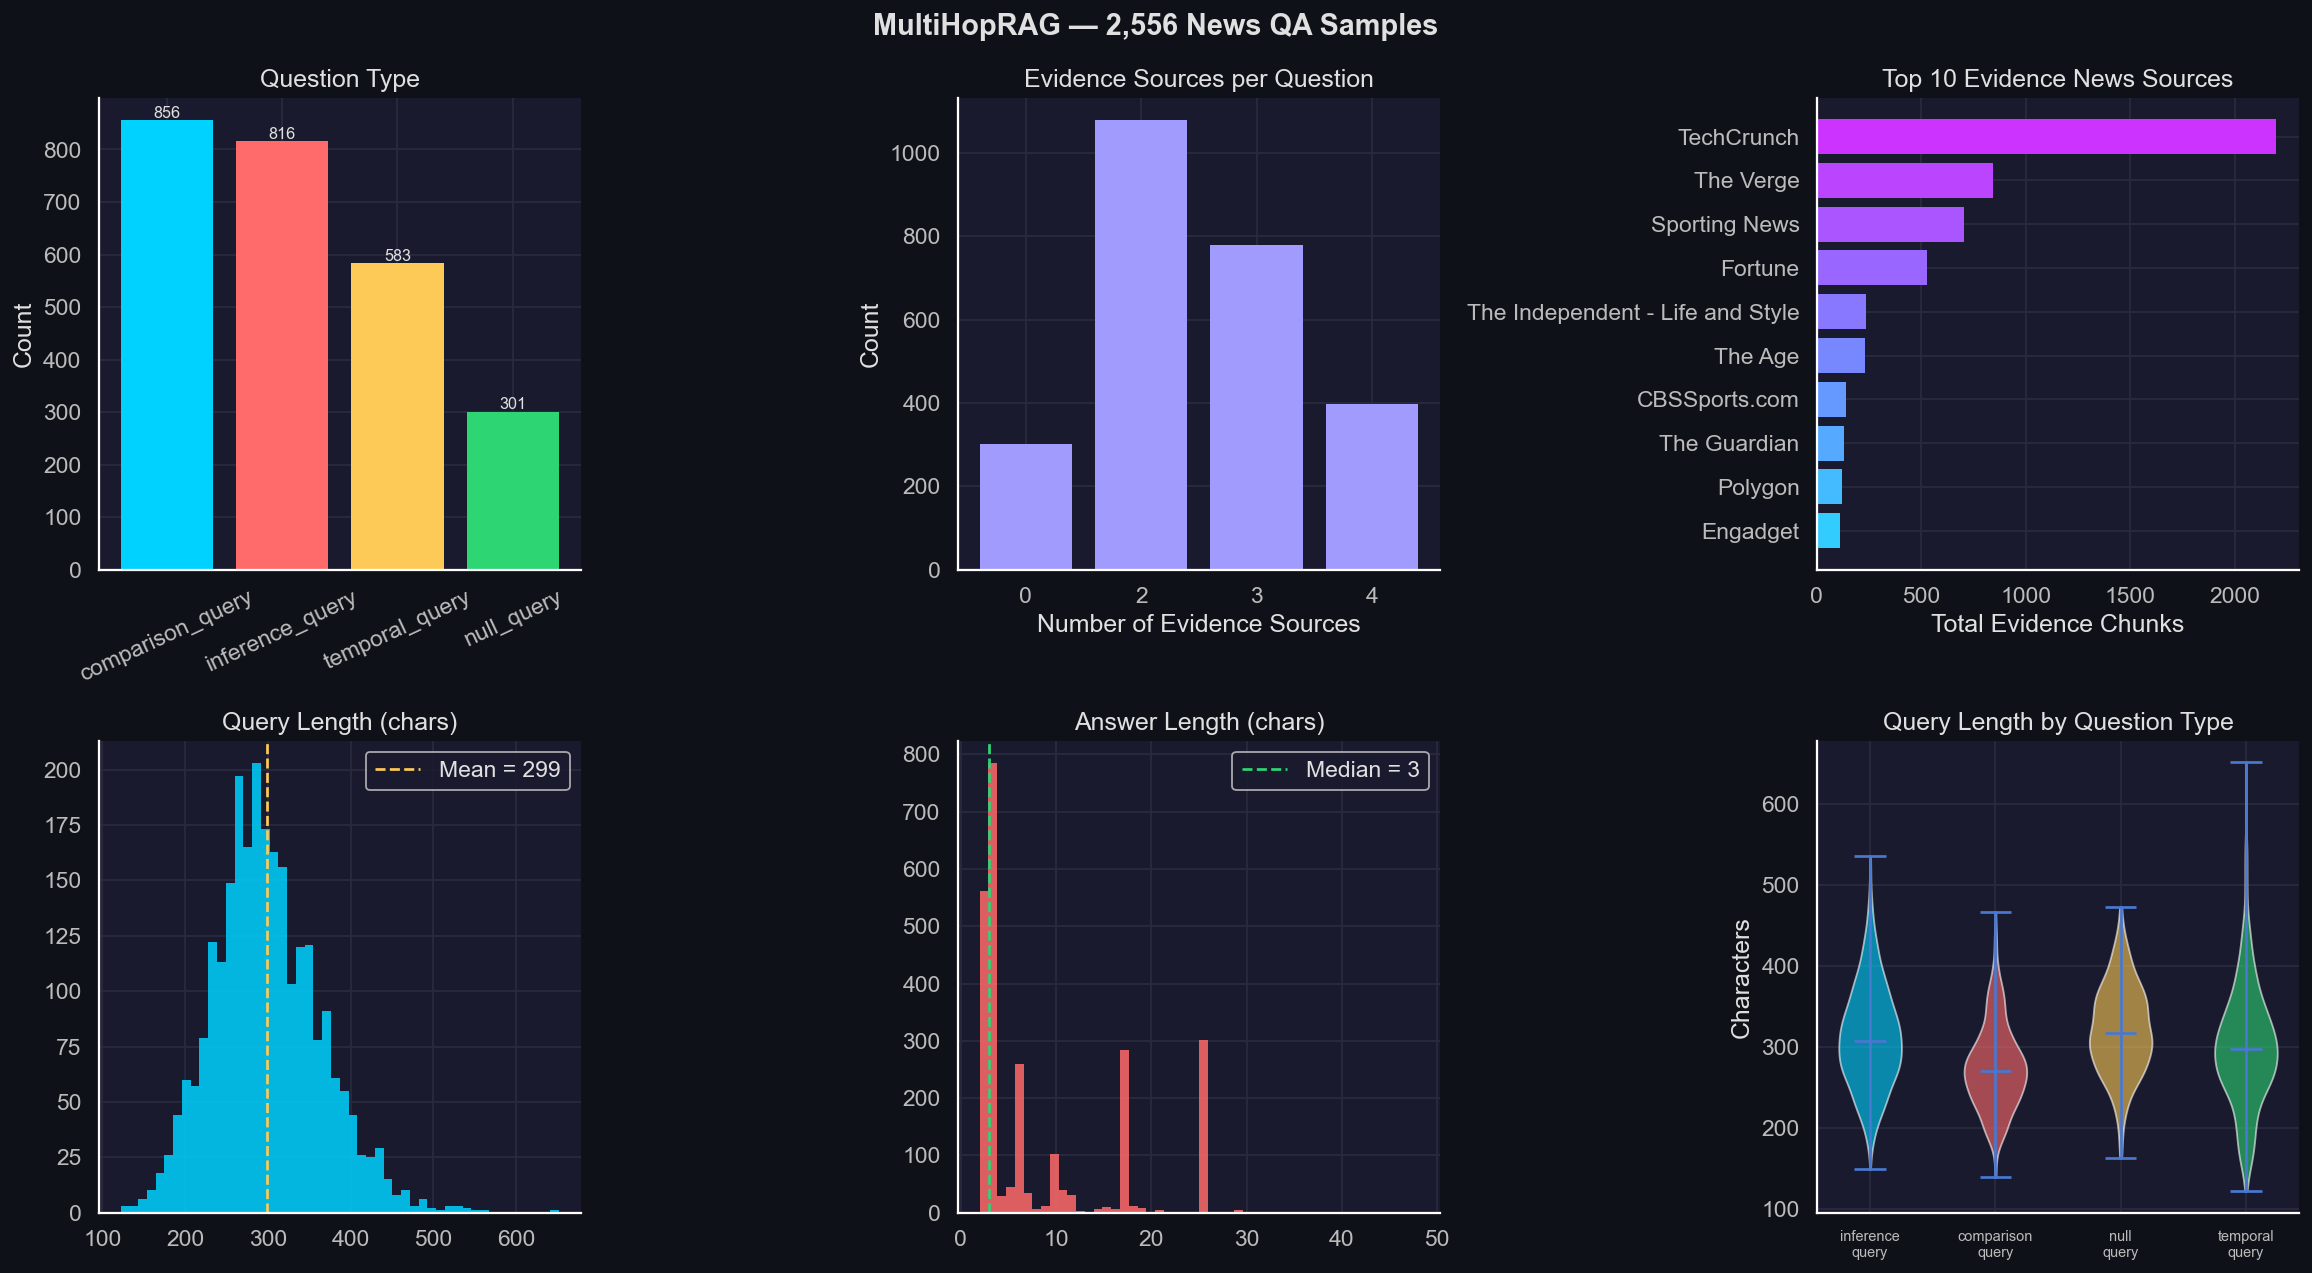

In [7]:
df_mhrag["q_len"]    = df_mhrag["query"].str.len()
df_mhrag["ans_len"]  = df_mhrag["answer"].str.len()
df_mhrag["n_evidences"] = df_mhrag["evidence_list"].apply(len)

# Extract news sources
all_sources = []
for ev_list in df_mhrag["evidence_list"]:
    for ev in ev_list:
        all_sources.append(ev.get("source", "Unknown"))
source_counts = Counter(all_sources)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("MultiHopRAG — 2,556 News QA Samples",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# Question type
qt_counts = df_mhrag["question_type"].value_counts()
axes[0,0].bar(qt_counts.index, qt_counts.values,
              color=PALETTE[:len(qt_counts)], edgecolor="none")
axes[0,0].set_title("Question Type")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis="x", rotation=25)
for i, val in enumerate(qt_counts.values):
    axes[0,0].text(i, val + 5, f"{val:,}", ha="center", fontsize=9, color="#e0e0e0")

# Evidence count distribution
ev_counts = df_mhrag["n_evidences"].value_counts().sort_index()
axes[0,1].bar(ev_counts.index.astype(str), ev_counts.values,
              color=PALETTE[4], edgecolor="none")
axes[0,1].set_title("Evidence Sources per Question")
axes[0,1].set_xlabel("Number of Evidence Sources")
axes[0,1].set_ylabel("Count")

# Top news sources
top_sources = dict(source_counts.most_common(10))
colors = plt.cm.cool(np.linspace(0.2, 0.8, len(top_sources)))
axes[0,2].barh(list(top_sources.keys())[::-1], list(top_sources.values())[::-1],
               color=colors, edgecolor="none")
axes[0,2].set_title("Top 10 Evidence News Sources")
axes[0,2].set_xlabel("Total Evidence Chunks")

# Query length
axes[1,0].hist(df_mhrag["q_len"], bins=50, color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[1,0].axvline(df_mhrag["q_len"].mean(), color="#feca57", linestyle="--", lw=1.5,
                   label=f"Mean = {df_mhrag['q_len'].mean():.0f}")
axes[1,0].set_title("Query Length (chars)")
axes[1,0].legend()

# Answer length
axes[1,1].hist(df_mhrag["ans_len"], bins=50, color=PALETTE[1], edgecolor="none", alpha=0.85)
axes[1,1].axvline(df_mhrag["ans_len"].median(), color="#2ed573", linestyle="--", lw=1.5,
                   label=f"Median = {df_mhrag['ans_len'].median():.0f}")
axes[1,1].set_title("Answer Length (chars)")
axes[1,1].legend()

# Q length by question type (violin)
qt_types = df_mhrag["question_type"].unique()
violin_data = [df_mhrag[df_mhrag["question_type"] == qt]["q_len"].values for qt in qt_types]
vp = axes[1,2].violinplot(violin_data, showmedians=True)
for i, (body, color) in enumerate(zip(vp["bodies"], PALETTE)):
    body.set_facecolor(color)
    body.set_alpha(0.6)
axes[1,2].set_xticks(range(1, len(qt_types)+1))
axes[1,2].set_xticklabels([t.replace("_", "\n") for t in qt_types], fontsize=8)
axes[1,2].set_title("Query Length by Question Type")
axes[1,2].set_ylabel("Characters")

plt.tight_layout()
plt.show()

## 6  TruthfulQA — Adversarial Misconception Testing

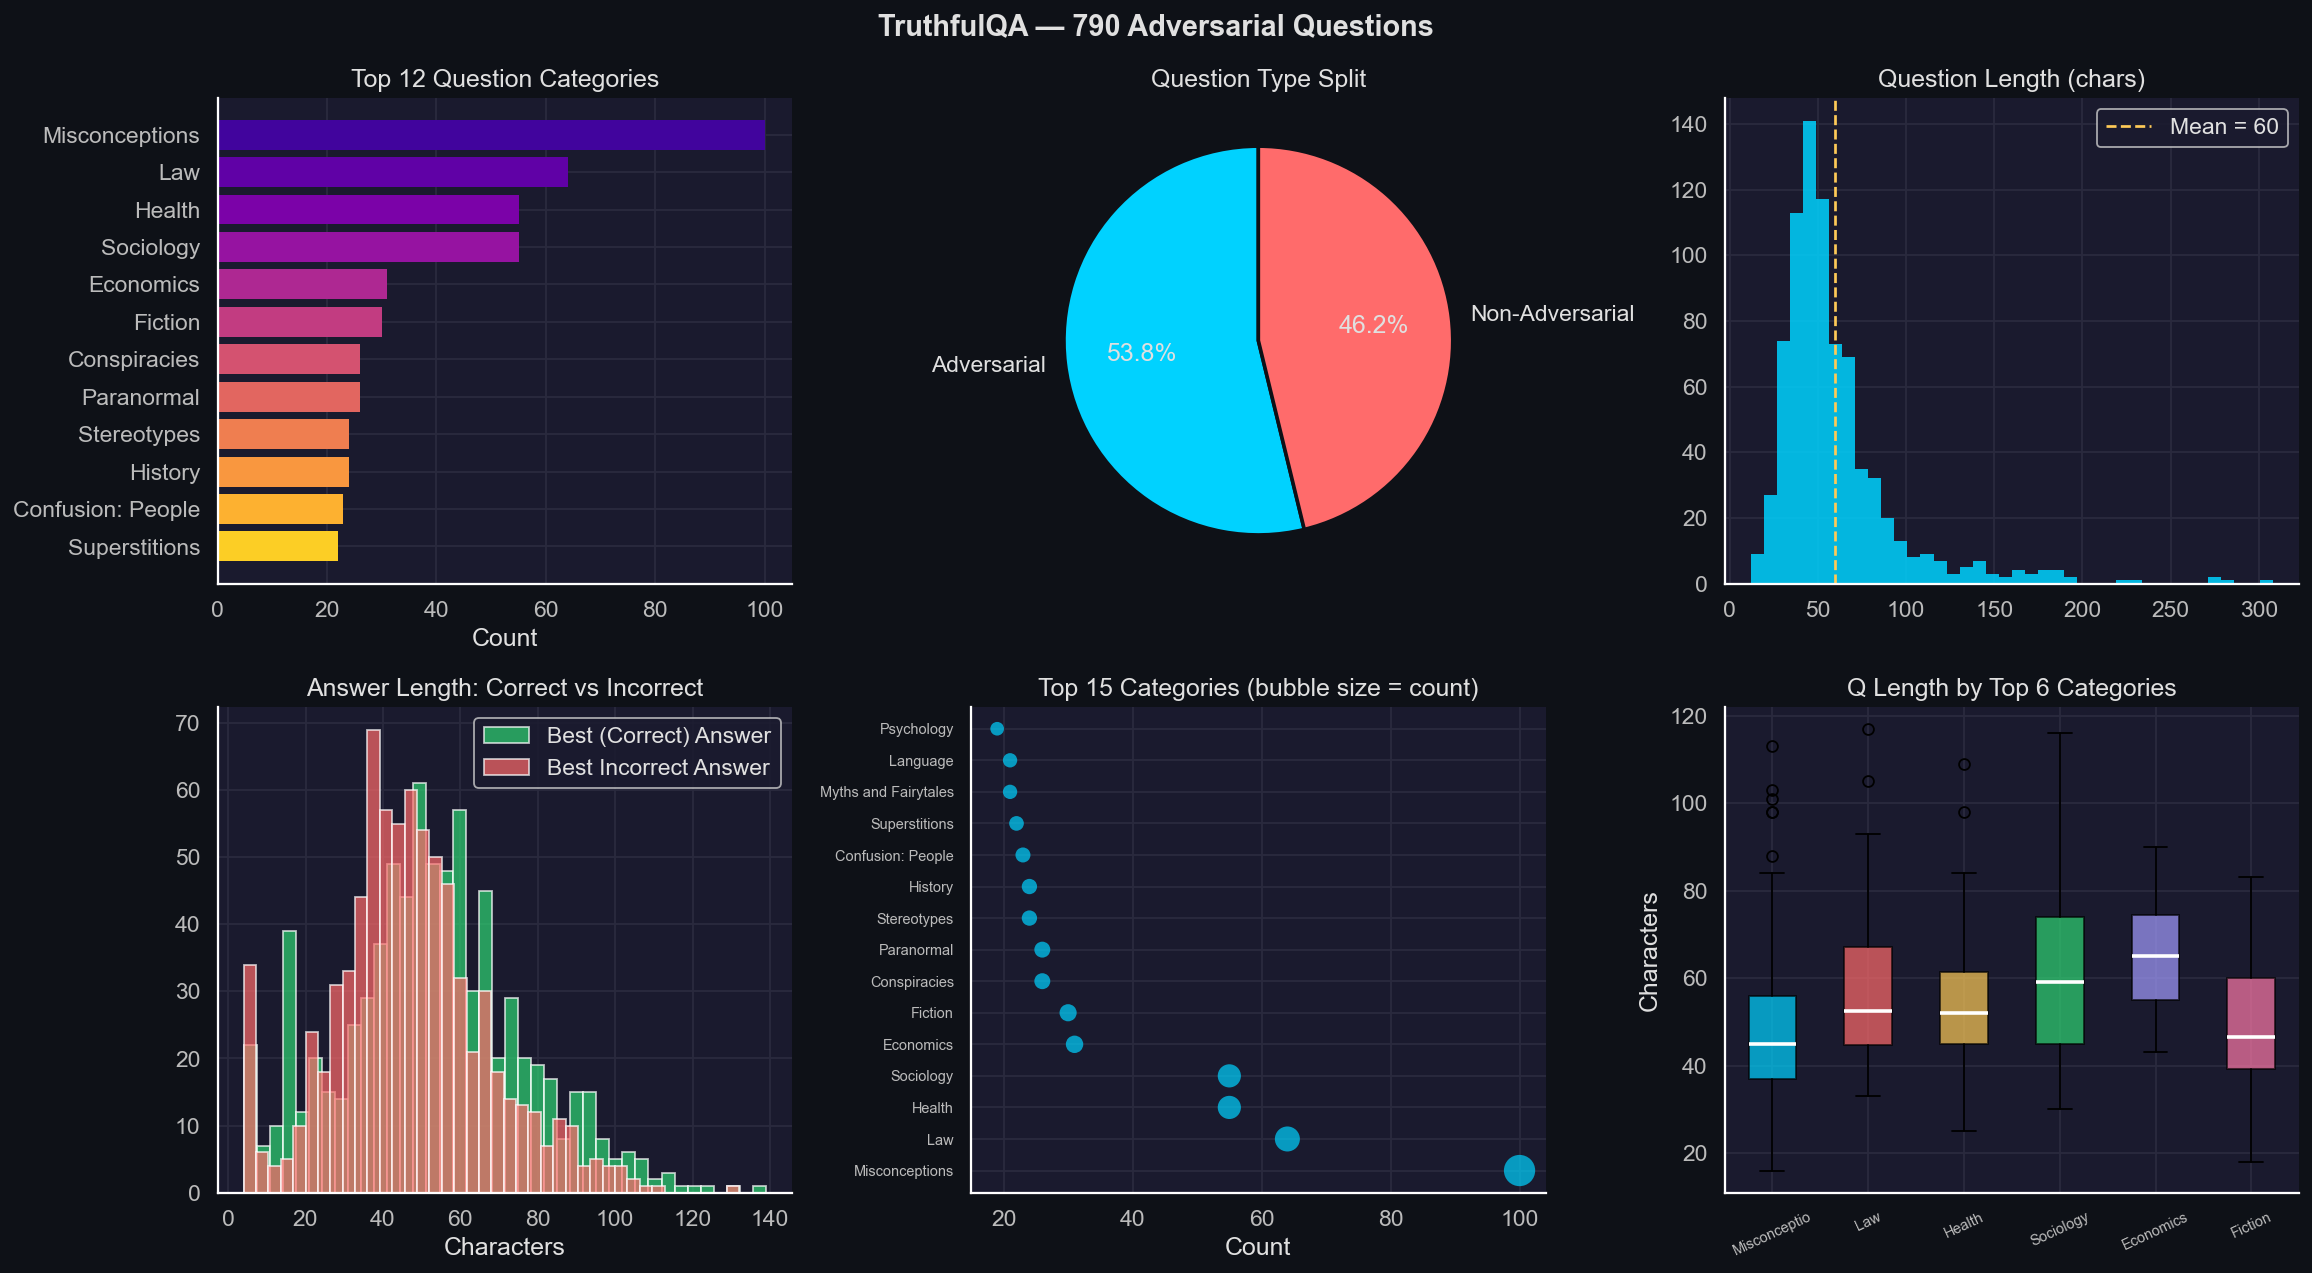

In [8]:
df_truth["q_len"]   = df_truth["Question"].str.len()
df_truth["ba_len"]  = df_truth["Best Answer"].str.len()
df_truth["bia_len"] = df_truth["Best Incorrect Answer"].str.len()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("TruthfulQA — 790 Adversarial Questions",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# Category distribution
cat_counts = df_truth["Category"].value_counts().head(12)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(cat_counts)))
axes[0,0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color=colors[::-1], edgecolor="none")
axes[0,0].set_title("Top 12 Question Categories")
axes[0,0].set_xlabel("Count")

# Type distribution
type_counts = df_truth["Type"].value_counts()
axes[0,1].pie(type_counts.values, labels=type_counts.index,
              colors=PALETTE[:len(type_counts)],
              autopct="%1.1f%%", startangle=90,
              wedgeprops=dict(edgecolor="#0e1117", lw=2),
              textprops=dict(color="#e0e0e0"))
axes[0,1].set_title("Question Type Split")
axes[0,1].set_facecolor("#0e1117")

# Question length
axes[0,2].hist(df_truth["q_len"], bins=40, color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[0,2].axvline(df_truth["q_len"].mean(), color="#feca57", linestyle="--", lw=1.5,
                   label=f"Mean = {df_truth['q_len'].mean():.0f}")
axes[0,2].set_title("Question Length (chars)")
axes[0,2].legend()

# Best Answer vs Best Incorrect Answer length
axes[1,0].hist(df_truth["ba_len"],  bins=40, color=PALETTE[3], alpha=0.7, label="Best (Correct) Answer")
axes[1,0].hist(df_truth["bia_len"], bins=40, color=PALETTE[1], alpha=0.7, label="Best Incorrect Answer")
axes[1,0].set_title("Answer Length: Correct vs Incorrect")
axes[1,0].set_xlabel("Characters")
axes[1,0].legend()

# Top 15 categories bubble-style (horizontal bar with counts)
top_cats = df_truth["Category"].value_counts().head(15)
axes[1,1].scatter(top_cats.values, range(len(top_cats)),
                  s=top_cats.values * 3, c=PALETTE[0], alpha=0.7, edgecolors="none")
axes[1,1].set_yticks(range(len(top_cats)))
axes[1,1].set_yticklabels(top_cats.index, fontsize=8)
axes[1,1].set_xlabel("Count")
axes[1,1].set_title("Top 15 Categories (bubble size = count)")

# Q length by category (top 6)
top6 = df_truth["Category"].value_counts().head(6).index.tolist()
box_data = [df_truth[df_truth["Category"] == cat]["q_len"].values for cat in top6]
bp = axes[1,2].boxplot(box_data, patch_artist=True,
                        medianprops=dict(color="white", lw=2))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,2].set_xticks(range(1, len(top6)+1))
axes[1,2].set_xticklabels([c[:12] for c in top6], rotation=25, fontsize=8)
axes[1,2].set_title("Q Length by Top 6 Categories")
axes[1,2].set_ylabel("Characters")

plt.tight_layout()
plt.show()

## 7  SQuAD v2 — Reading Comprehension

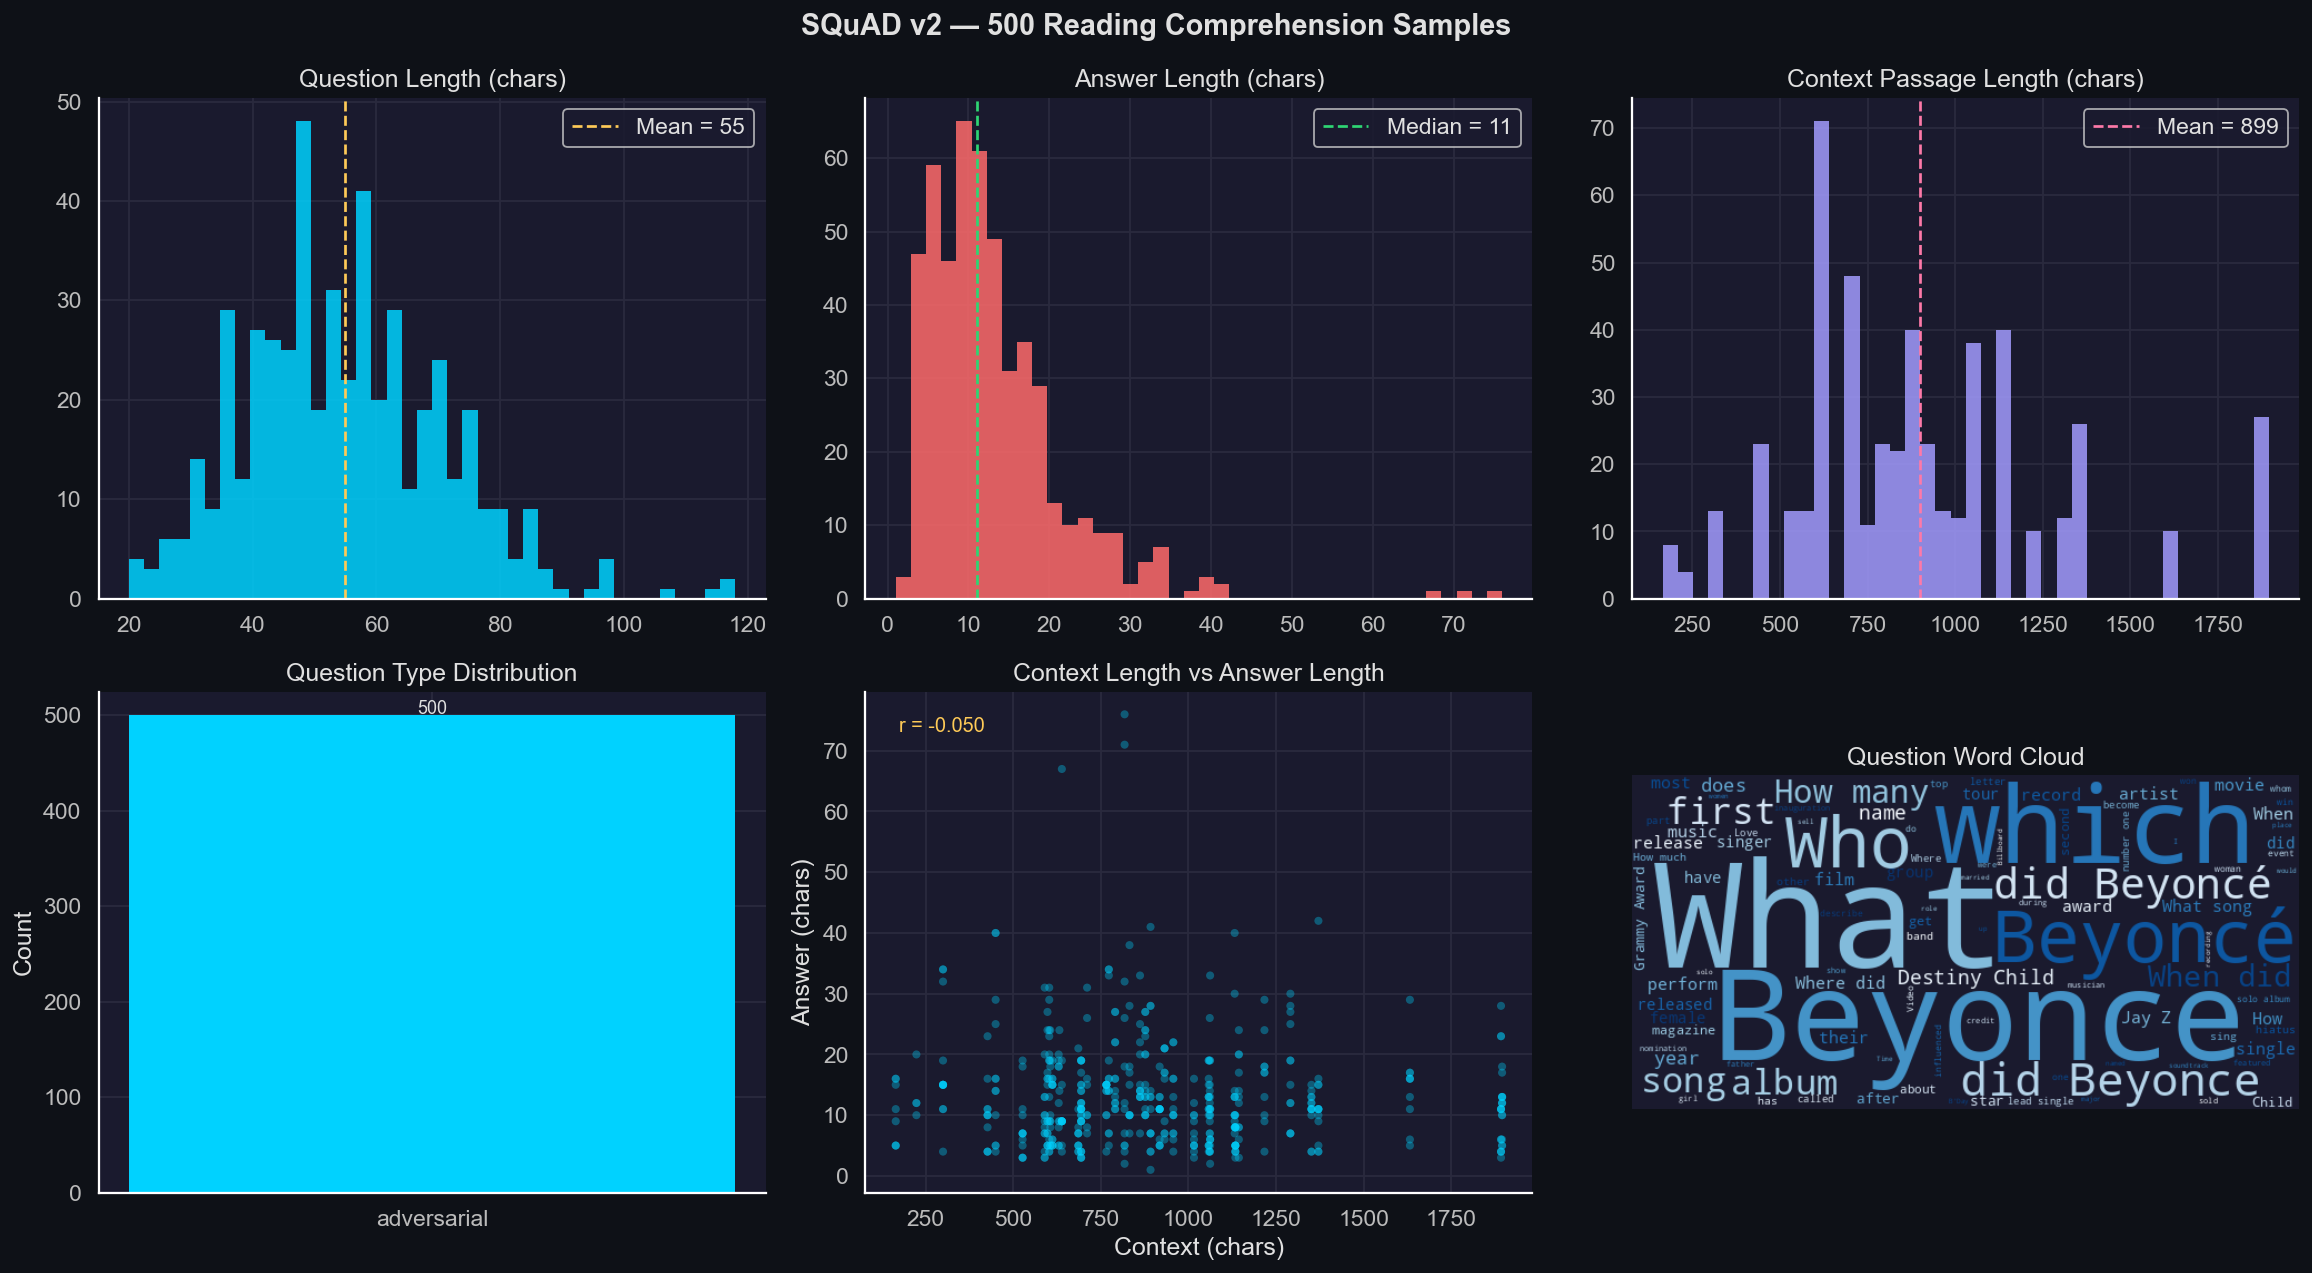

In [9]:
df_squad["q_len"]   = df_squad["question"].str.len()
df_squad["ans_len"] = df_squad["answer"].str.len()
df_squad["ctx_len"] = df_squad["context"].str.len()

# Extract metadata fields
df_squad["source"] = df_squad["metadata"].apply(lambda m: m.get("source", "Unknown"))
df_squad["q_type"] = df_squad["metadata"].apply(lambda m: m.get("type", "Unknown"))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("SQuAD v2 — 500 Reading Comprehension Samples",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# Question length
axes[0,0].hist(df_squad["q_len"], bins=40, color=PALETTE[0], edgecolor="none", alpha=0.85)
axes[0,0].axvline(df_squad["q_len"].mean(), color="#feca57", linestyle="--", lw=1.5,
                   label=f"Mean = {df_squad['q_len'].mean():.0f}")
axes[0,0].set_title("Question Length (chars)")
axes[0,0].legend()

# Answer length
axes[0,1].hist(df_squad["ans_len"], bins=40, color=PALETTE[1], edgecolor="none", alpha=0.85)
axes[0,1].axvline(df_squad["ans_len"].median(), color="#2ed573", linestyle="--", lw=1.5,
                   label=f"Median = {df_squad['ans_len'].median():.0f}")
axes[0,1].set_title("Answer Length (chars)")
axes[0,1].legend()

# Context passage length
axes[0,2].hist(df_squad["ctx_len"], bins=40, color=PALETTE[4], edgecolor="none", alpha=0.85)
axes[0,2].axvline(df_squad["ctx_len"].mean(), color="#fd79a8", linestyle="--", lw=1.5,
                   label=f"Mean = {df_squad['ctx_len'].mean():.0f}")
axes[0,2].set_title("Context Passage Length (chars)")
axes[0,2].legend()

# Q type split
qtype_counts = df_squad["q_type"].value_counts()
axes[1,0].bar(qtype_counts.index, qtype_counts.values,
              color=PALETTE[:len(qtype_counts)], edgecolor="none")
axes[1,0].set_title("Question Type Distribution")
axes[1,0].set_ylabel("Count")
for i, val in enumerate(qtype_counts.values):
    axes[1,0].text(i, val + 2, str(val), ha="center", fontsize=10, color="#e0e0e0")

# Scatter: context length vs answer length
axes[1,1].scatter(df_squad["ctx_len"], df_squad["ans_len"],
                  alpha=0.35, s=20, c=PALETTE[0], edgecolors="none")
axes[1,1].set_title("Context Length vs Answer Length")
axes[1,1].set_xlabel("Context (chars)")
axes[1,1].set_ylabel("Answer (chars)")
corr = df_squad[["ctx_len","ans_len"]].corr().iloc[0,1]
axes[1,1].annotate(f"r = {corr:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
                    fontsize=11, color="#feca57")

# Word cloud — questions
q_text = " ".join(df_squad["question"].tolist())
wc = WordCloud(
    width=600, height=300, background_color="#1a1a2e",
    colormap="Blues", max_words=100,
    stopwords={"the","a","an","is","was","in","of","and","to","it","that",
               "for","on","are","at","be","this","with","his","her","not",
               "as","by","from","or","its","he","she","they"},
).generate(q_text)
axes[1,2].imshow(wc, interpolation="bilinear")
axes[1,2].axis("off")
axes[1,2].set_title("Question Word Cloud")

plt.tight_layout()
plt.show()

## 8  Cross-Dataset Comparison

/var/folders/92/7fcb7w911b3g8vck3tlsrx1m0000gn/T/ipykernel_12953/2701801352.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(bp_data, labels=bp_names, patch_artist=True,


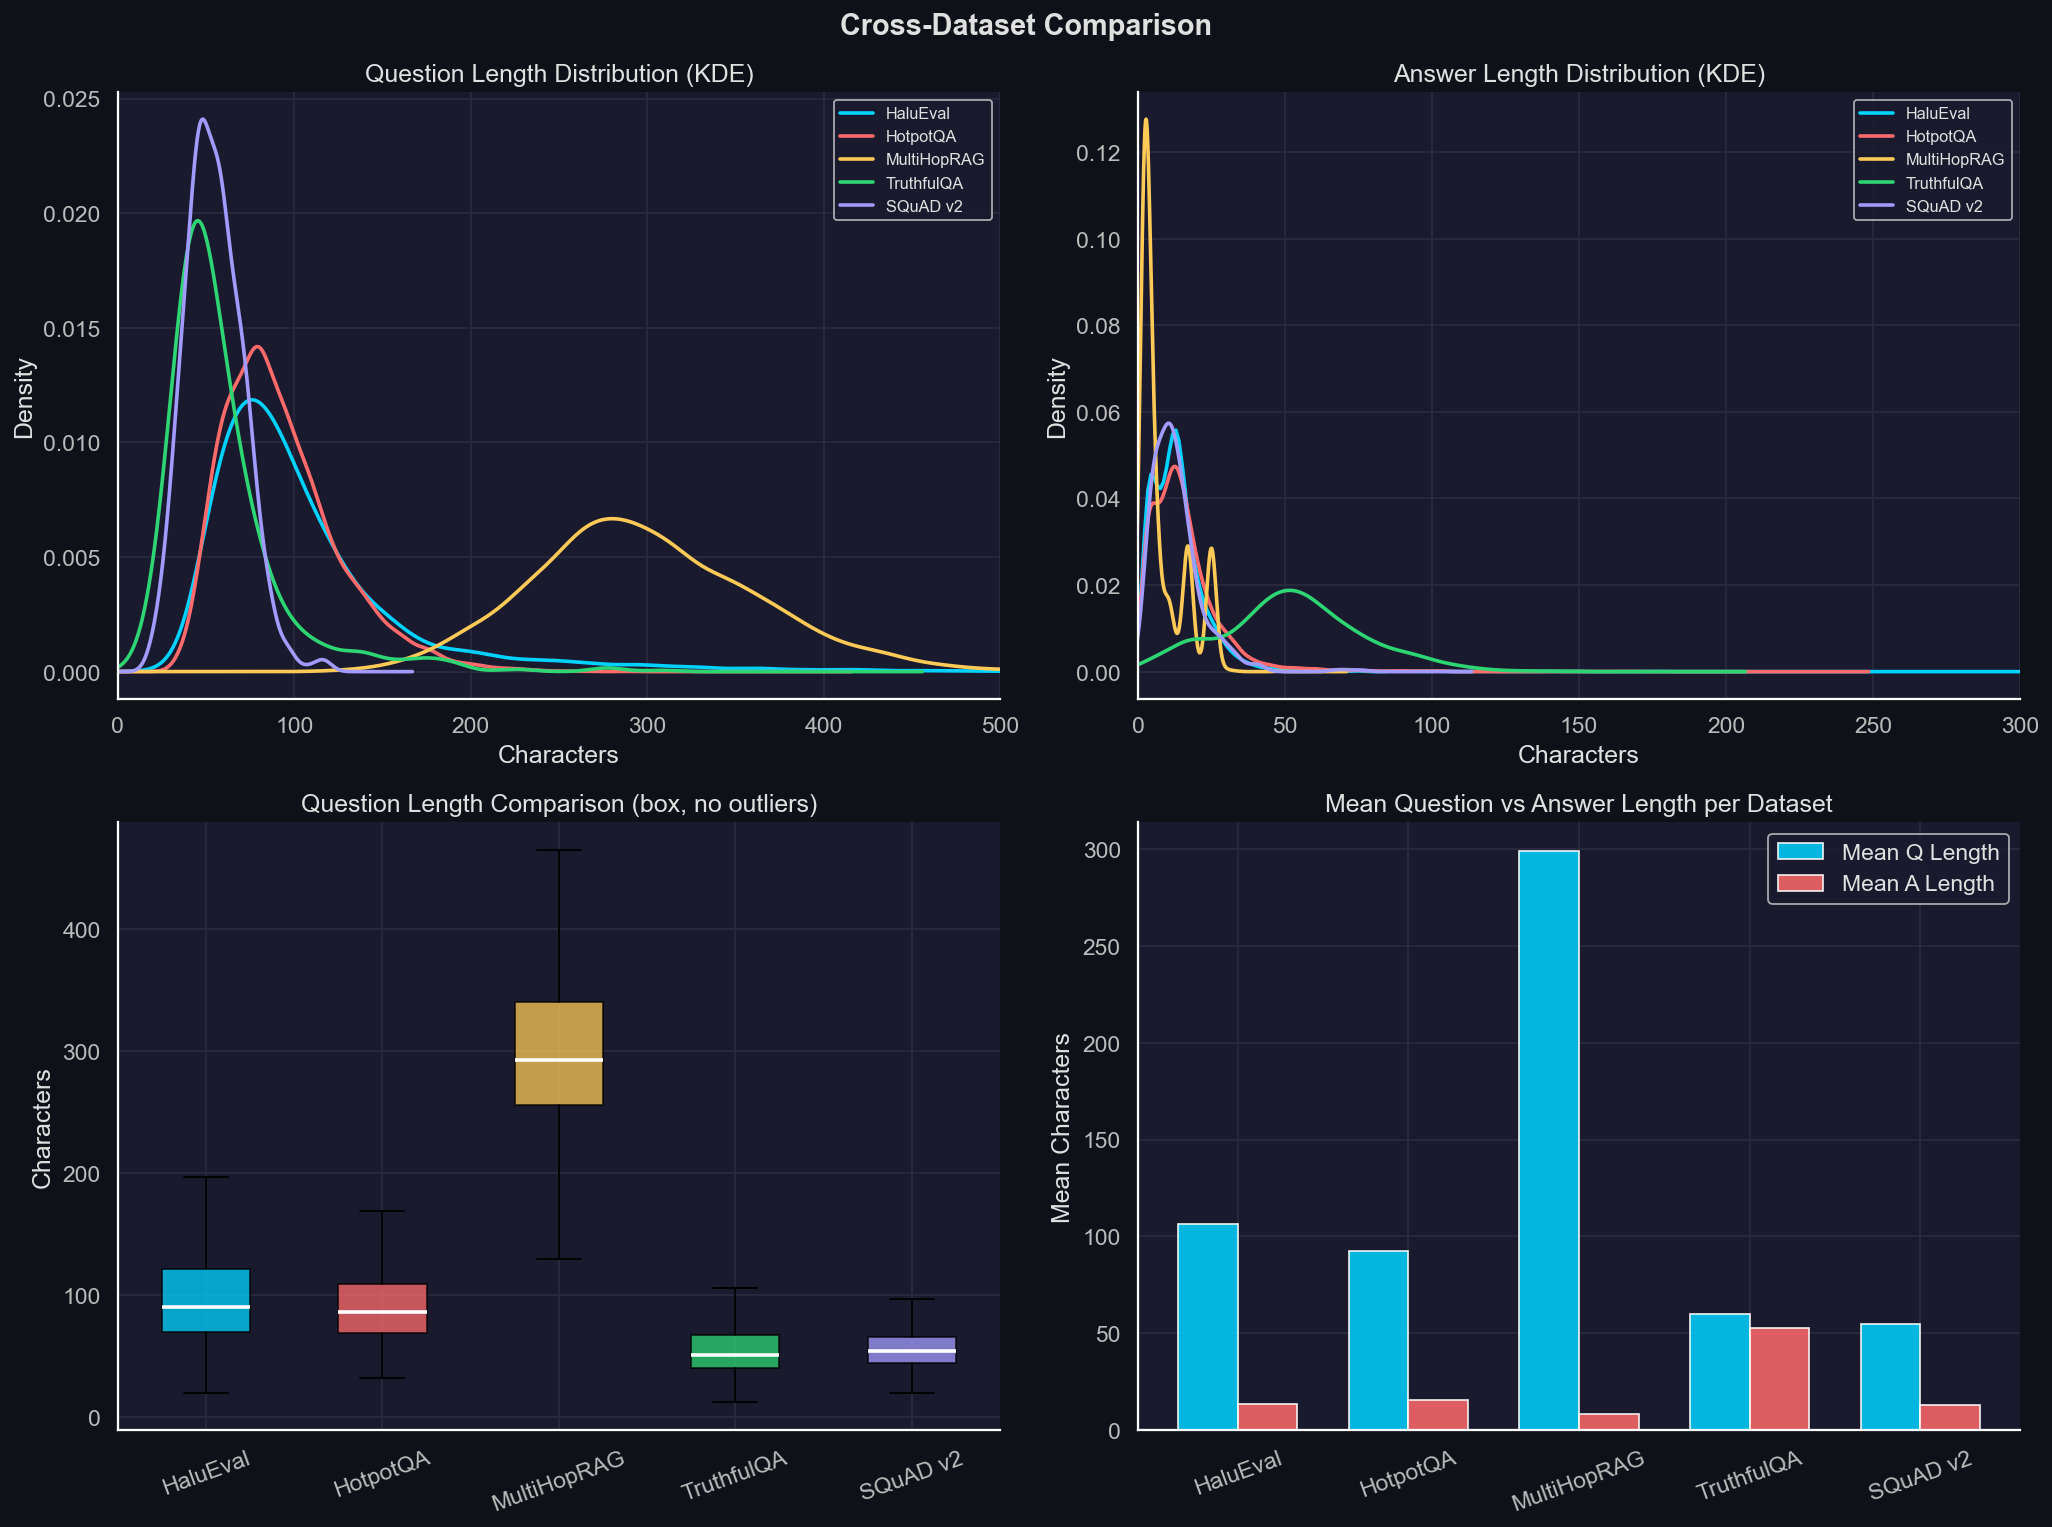

In [10]:
# Unified question-length series
q_lengths = {
    "HaluEval":    df_halu["q_len"],
    "HotpotQA":    df_hotpot["q_len"],
    "MultiHopRAG": df_mhrag["q_len"],
    "TruthfulQA":  df_truth["q_len"],
    "SQuAD v2":    df_squad["q_len"],
}
a_lengths = {
    "HaluEval":    df_halu["right_len"],
    "HotpotQA":    df_hotpot["ans_len"],
    "MultiHopRAG": df_mhrag["ans_len"],
    "TruthfulQA":  df_truth["ba_len"],
    "SQuAD v2":    df_squad["ans_len"],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("Cross-Dataset Comparison",
             fontsize=16, fontweight="bold", color="#e0e0e0")

# KDE: question lengths
for (name, series), color in zip(q_lengths.items(), PALETTE):
    series.plot.kde(ax=axes[0,0], label=name, color=color, lw=2)
axes[0,0].set_title("Question Length Distribution (KDE)")
axes[0,0].set_xlabel("Characters")
axes[0,0].set_xlim(0, 500)
axes[0,0].legend(fontsize=9)

# KDE: answer lengths
for (name, series), color in zip(a_lengths.items(), PALETTE):
    series.plot.kde(ax=axes[0,1], label=name, color=color, lw=2)
axes[0,1].set_title("Answer Length Distribution (KDE)")
axes[0,1].set_xlabel("Characters")
axes[0,1].set_xlim(0, 300)
axes[0,1].legend(fontsize=9)

# Box plot: question length side-by-side
bp_data  = [series.values for series in q_lengths.values()]
bp_names = list(q_lengths.keys())
bp = axes[1,0].boxplot(bp_data, labels=bp_names, patch_artist=True,
                        medianprops=dict(color="white", lw=2), showfliers=False)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1,0].set_title("Question Length Comparison (box, no outliers)")
axes[1,0].set_ylabel("Characters")
axes[1,0].tick_params(axis="x", rotation=20)

# Grouped bar: mean Q length vs mean A length
ds_names = list(q_lengths.keys())
q_means  = [s.mean() for s in q_lengths.values()]
a_means  = [s.mean() for s in a_lengths.values()]
x = np.arange(len(ds_names))
w = 0.35
axes[1,1].bar(x - w/2, q_means, w, label="Mean Q Length", color=PALETTE[0], alpha=0.85)
axes[1,1].bar(x + w/2, a_means, w, label="Mean A Length", color=PALETTE[1], alpha=0.85)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(ds_names, rotation=20)
axes[1,1].set_title("Mean Question vs Answer Length per Dataset")
axes[1,1].set_ylabel("Mean Characters")
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 9  Summary Statistics Table

In [11]:
summary_rows = []
for name, (q_ser, a_ser) in {
    "HaluEval":    (df_halu["q_len"],    df_halu["right_len"]),
    "HotpotQA":    (df_hotpot["q_len"],  df_hotpot["ans_len"]),
    "MultiHopRAG": (df_mhrag["q_len"],   df_mhrag["ans_len"]),
    "TruthfulQA":  (df_truth["q_len"],   df_truth["ba_len"]),
    "SQuAD v2":    (df_squad["q_len"],   df_squad["ans_len"]),
}.items():
    summary_rows.append({
        "Dataset":        name,
        "Samples":        f"{len(q_ser):,}",
        "Q len (mean)": f"{q_ser.mean():.0f}",
        "Q len (median)": f"{q_ser.median():.0f}",
        "Q len (std)":    f"{q_ser.std():.0f}",
        "A len (mean)": f"{a_ser.mean():.0f}",
        "A len (median)": f"{a_ser.median():.0f}",
        "A len (std)":    f"{a_ser.std():.0f}",
    })

df_summary = pd.DataFrame(summary_rows).set_index("Dataset")
print("="*80)
print("COUNCIL MODE — BENCHMARK DATASET SUMMARY")
print("="*80)
print(df_summary.to_string())
print("="*80)
print(f"\nTotal samples: {sum(int(r.replace(',','')) for r in df_summary['Samples']):,}")

COUNCIL MODE — BENCHMARK DATASET SUMMARY
            Samples Q len (mean) Q len (median) Q len (std) A len (mean) A len (median) A len (std)
Dataset                                                                                            
HaluEval     10,000          106             90          61           14             12          12
HotpotQA      7,405           92             86          33           15             13          12
MultiHopRAG   2,556          299            293          64            8              3           8
TruthfulQA      790           60             51          35           53             52          24
SQuAD v2        500           55             54          16           13             11           9

Total samples: 21,251


## 10  Council Mode Difficulty Heatmap

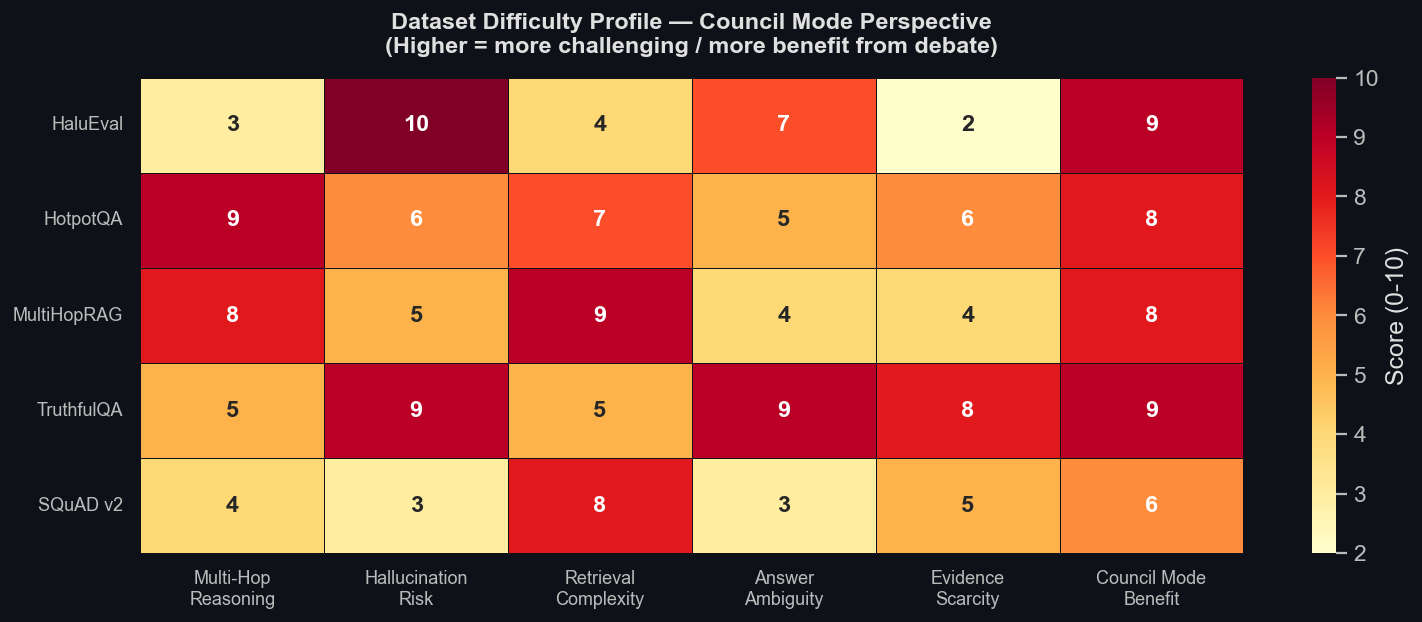


Insight: HaluEval and TruthfulQA have the highest hallucination risk,
making them the strongest signal datasets for Council Mode's debate pipeline.
MultiHopRAG and HotpotQA stress the retrieval and reasoning components.


In [12]:
# Characterize each dataset along axes relevant to Council Mode's task
# Scores are manual assessments (0-10) based on dataset design
difficulty_matrix = pd.DataFrame({
    "Multi-Hop\nReasoning":    [3, 9, 8, 5, 4],
    "Hallucination\nRisk":      [10, 6, 5, 9, 3],
    "Retrieval\nComplexity":    [4, 7, 9, 5, 8],
    "Answer\nAmbiguity":        [7, 5, 4, 9, 3],
    "Evidence\nScarcity":       [2, 6, 4, 8, 5],
    "Council Mode\nBenefit":    [9, 8, 8, 9, 6],
}, index=["HaluEval", "HotpotQA", "MultiHopRAG", "TruthfulQA", "SQuAD v2"])

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0e1117")

sns.heatmap(
    difficulty_matrix, ax=ax,
    cmap="YlOrRd", annot=True, fmt="d", linewidths=0.5,
    linecolor="#0e1117", cbar_kws={"label": "Score (0-10)"},
    annot_kws={"size": 13, "weight": "bold"},
)
ax.set_title("Dataset Difficulty Profile — Council Mode Perspective\n"
             "(Higher = more challenging / more benefit from debate)",
             fontsize=13, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

print("\nInsight: HaluEval and TruthfulQA have the highest hallucination risk,")
print("making them the strongest signal datasets for Council Mode's debate pipeline.")
print("MultiHopRAG and HotpotQA stress the retrieval and reasoning components.")

## 11  Key Takeaways for Council Mode

| Finding | Implication |
|---|---|
| HaluEval hallucinated answers are **on average longer** than correct ones | Models tend to add false detail — Skeptic should flag verbosity |
| HotpotQA has mostly **2 supporting facts** per question | Expert agents need multi-source synthesis |
| MultiHopRAG spans **10+ news sources** | Iterative re-retrieval is critical for high-quality answers |
| TruthfulQA covers **38 categories** with high topic variance | Triage Agent must route these to full Council debate |
| SQuAD v2 contexts average **~900 chars** | RAG chunk size of 512 may split passages — consider larger chunks |
| Question lengths are **consistent across datasets** (~60-90 chars mean) | Triage prompt is appropriately tuned |